# Task 1: Term Deposit Subscription Prediction
**DevelopersHub Corporation – Data Science & Analytics Advanced Internship**

## Problem Statement
Predict whether a bank customer will subscribe to a term deposit based on marketing campaign data. This is a binary classification problem using the UCI Bank Marketing Dataset.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, roc_curve, auc, ConfusionMatrixDisplay)
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Dataset Description & Loading
The **Bank Marketing Dataset** (UCI) contains data from direct marketing campaigns of a Portuguese banking institution. It has 45,211 rows and 17 columns. The target variable `y` indicates whether the client subscribed to a term deposit (`yes`/`no`).

In [3]:
# Load dataset from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"

import urllib.request, zipfile, io, os

# Download and extract
response = urllib.request.urlopen(url)
zip_data = zipfile.ZipFile(io.BytesIO(response.read()))
zip_data.extractall('/tmp/bank_data')

df = pd.read_csv('/tmp/bank_data/bank-full.csv', sep=';')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (45211, 17)

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print("Dataset Info:")
print(df.info())
print("\nMissing values:", df.isnull().sum().sum())
print("\nTarget Distribution:")
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Missing values: 0

Target Distribution:
y
no     39922
yes     5289
Name: count

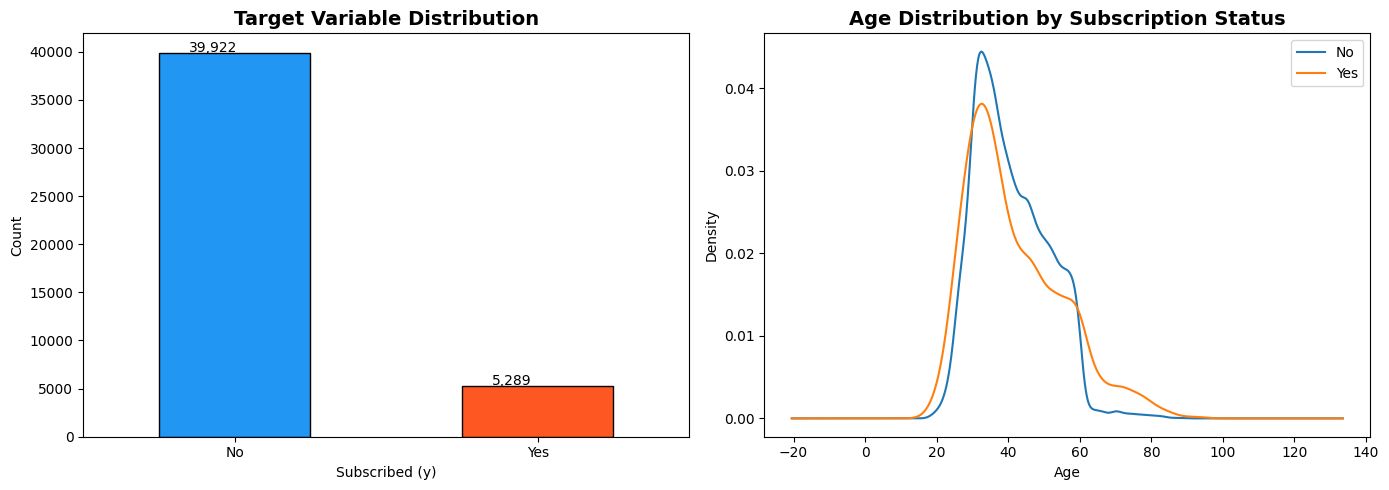

EDA plots saved.


In [5]:
# Target distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['y'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3','#FF5722'], edgecolor='black')
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+0.1, p.get_height()+100))

# Age distribution by target
df.groupby('y')['age'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Age Distribution by Subscription Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend(['No', 'Yes'])
plt.tight_layout()
plt.show()
print("EDA plots saved.")

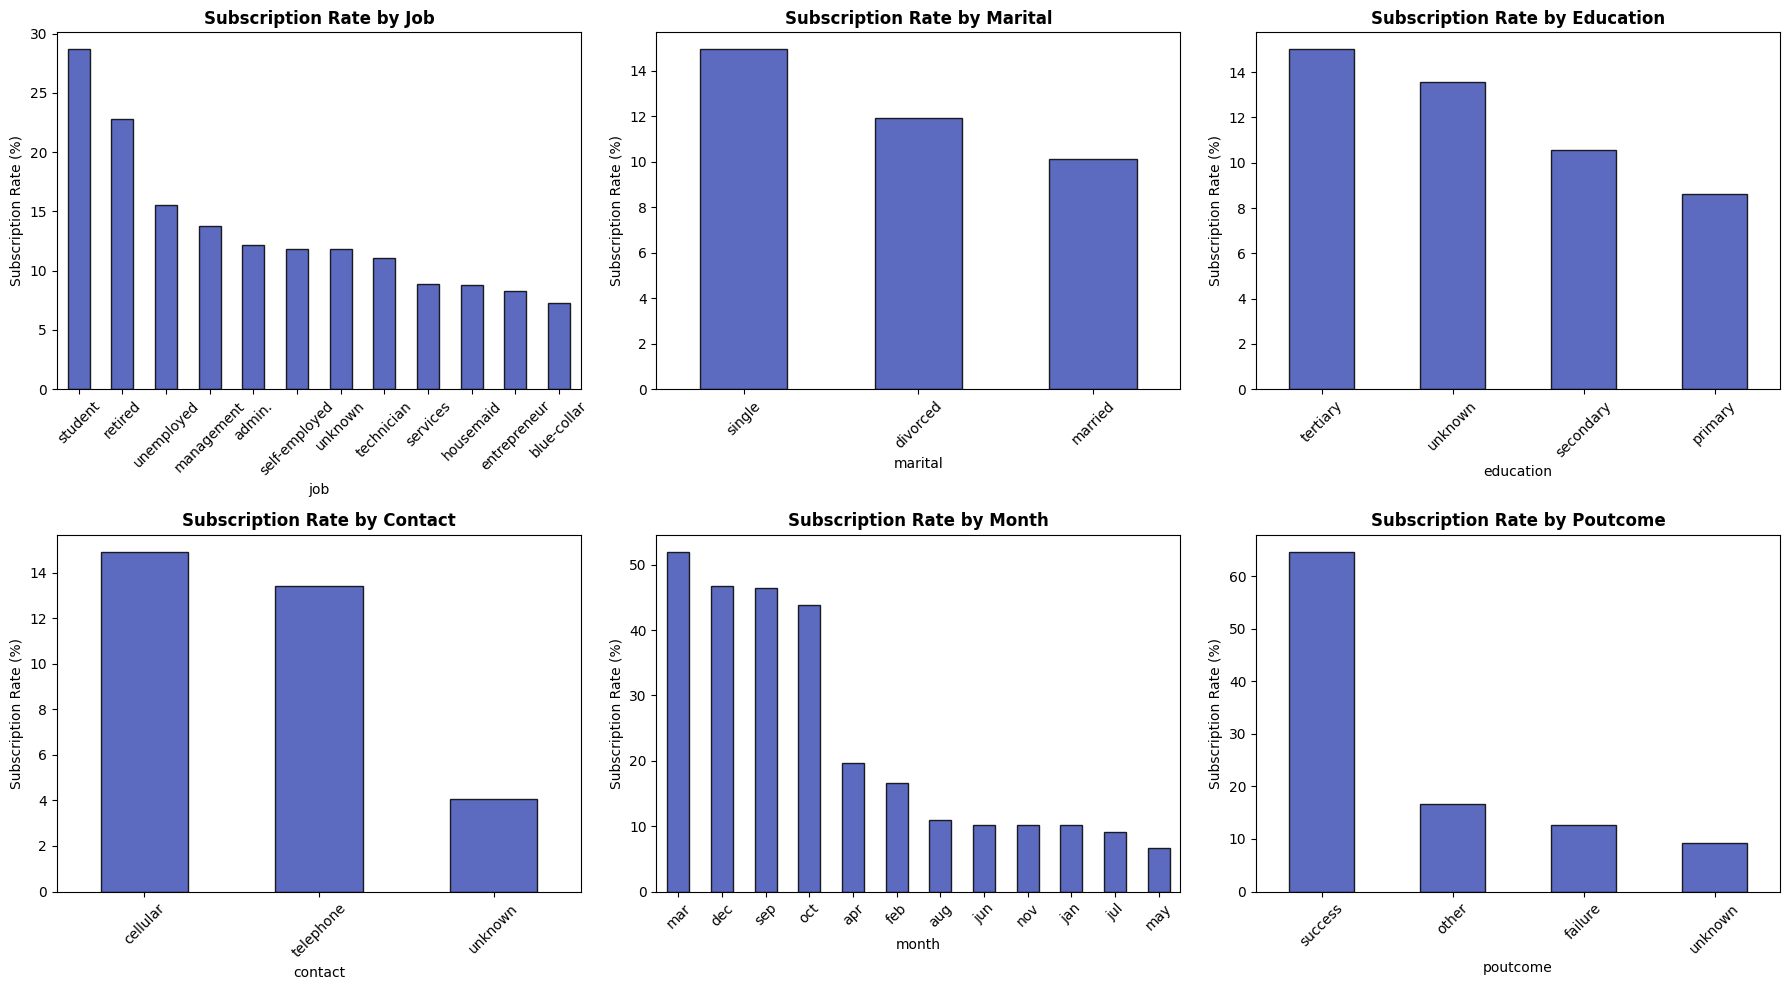

In [6]:
# Categorical feature analysis
cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sub_rate = df.groupby(col)['y'].apply(lambda x: (x=='yes').mean() * 100).sort_values(ascending=False)
    sub_rate.plot(kind='bar', ax=axes[i], color='#3F51B5', edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Subscription Rate by {col.capitalize()}', fontweight='bold')
    axes[i].set_ylabel('Subscription Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

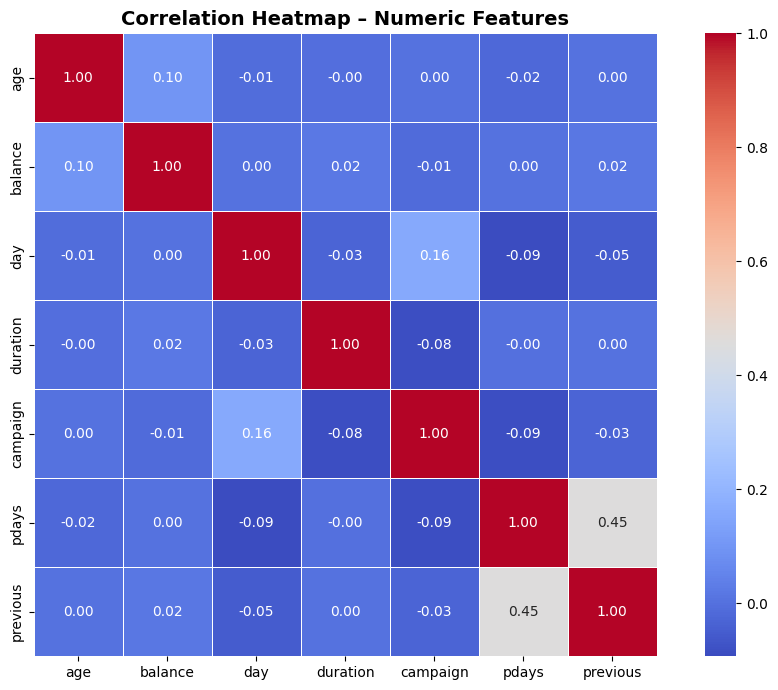

In [7]:
# Correlation heatmap (numeric features)
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap – Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Cleaning & Preprocessing

In [8]:
# Encode categorical features
df_enc = df.copy()
le = LabelEncoder()

cat_features = df_enc.select_dtypes(include='object').columns.tolist()
cat_features.remove('y')  # Don't encode target yet

for col in cat_features:
    df_enc[col] = le.fit_transform(df_enc[col])

# Encode target
df_enc['y'] = (df_enc['y'] == 'yes').astype(int)

print("Categorical features encoded:")
print(cat_features)
print(f"\nClass balance after encoding:")
print(df_enc['y'].value_counts())

Categorical features encoded:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Class balance after encoding:
y
0    39922
1     5289
Name: count, dtype: int64


In [9]:
# Feature/target split and train-test split
X = df_enc.drop('y', axis=1)
y = df_enc['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 36168 | Test size: 9043


## 5. Model Building & Evaluation

In [10]:
# ── Logistic Regression ──
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(classification_report(y_test, lr_preds, target_names=['No', 'Yes']))
print(f"F1-Score (macro): {f1_score(y_test, lr_preds, average='macro'):.4f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

          No       0.97      0.81      0.88      7985
         Yes       0.36      0.80      0.50      1058

    accuracy                           0.81      9043
   macro avg       0.66      0.81      0.69      9043
weighted avg       0.90      0.81      0.84      9043

F1-Score (macro): 0.6892


In [11]:
# ── Random Forest ──
rf = RandomForestClassifier(n_estimators=200, random_state=42, 
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, rf_preds, target_names=['No', 'Yes']))
print(f"F1-Score (macro): {f1_score(y_test, rf_preds, average='macro'):.4f}")

RANDOM FOREST
              precision    recall  f1-score   support

          No       0.92      0.98      0.95      7985
         Yes       0.67      0.36      0.47      1058

    accuracy                           0.90      9043
   macro avg       0.80      0.67      0.71      9043
weighted avg       0.89      0.90      0.89      9043

F1-Score (macro): 0.7074


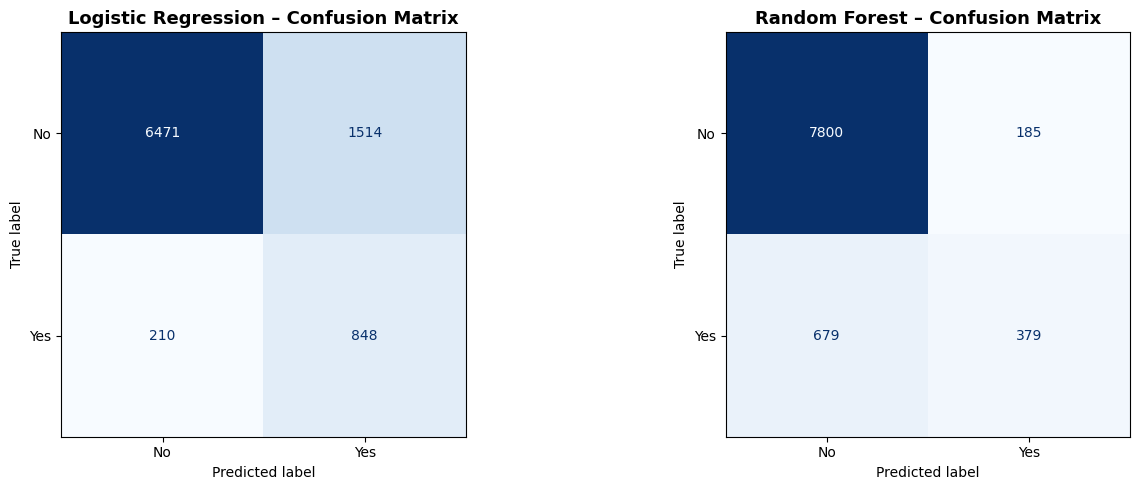

In [12]:
# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name in zip(axes, [lr_preds, rf_preds], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} – Confusion Matrix', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

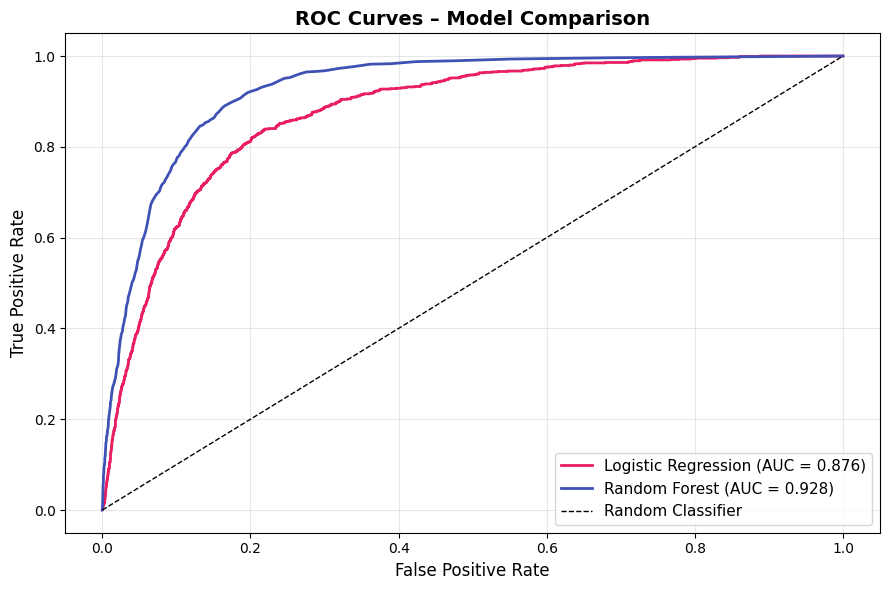

In [13]:
# ── ROC Curves ──
plt.figure(figsize=(9, 6))

for proba, name, color in [(lr_proba, 'Logistic Regression', '#E91E63'),
                            (rf_proba, 'Random Forest', '#3F51B5')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves – Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

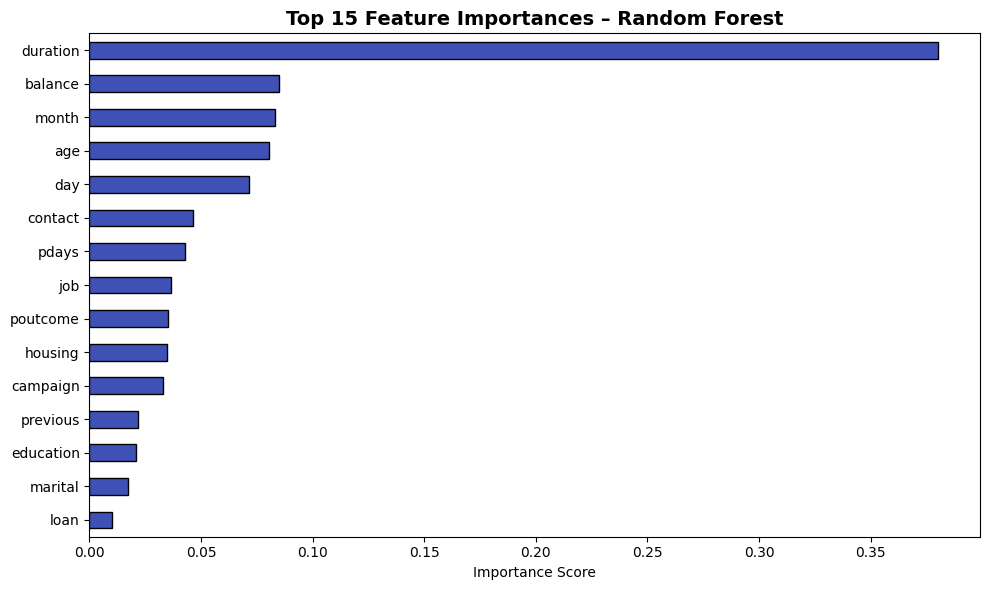

In [14]:
# ── Feature Importance (Random Forest) ──
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='#3F51B5', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances – Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 6. Explainable AI with SHAP
Using SHAP (SHapley Additive exPlanations) to explain 5 individual model predictions.

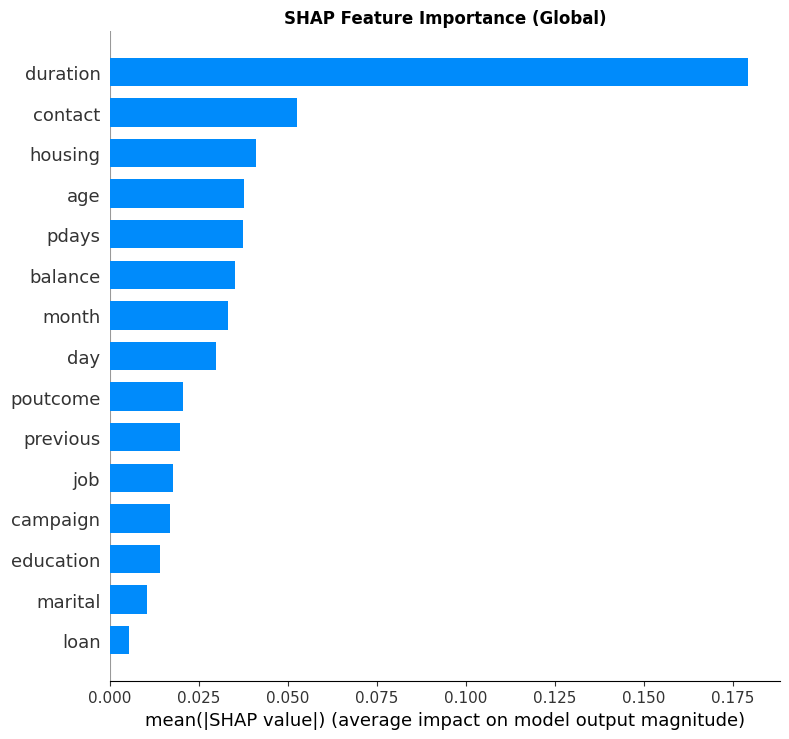

In [15]:
# SHAP explanation for Random Forest
explainer = shap.TreeExplainer(rf)
X_test_sample = X_test.iloc[:100]  # Use a sample for speed
shap_values = explainer.shap_values(X_test_sample)

# Summary plot
plt.figure()
shap.summary_plot(shap_values[:,:,1] if len(np.array(shap_values).shape)==3 else shap_values[1], 
                  X_test_sample, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance (Global)', fontweight='bold')
plt.tight_layout()
plt.show()

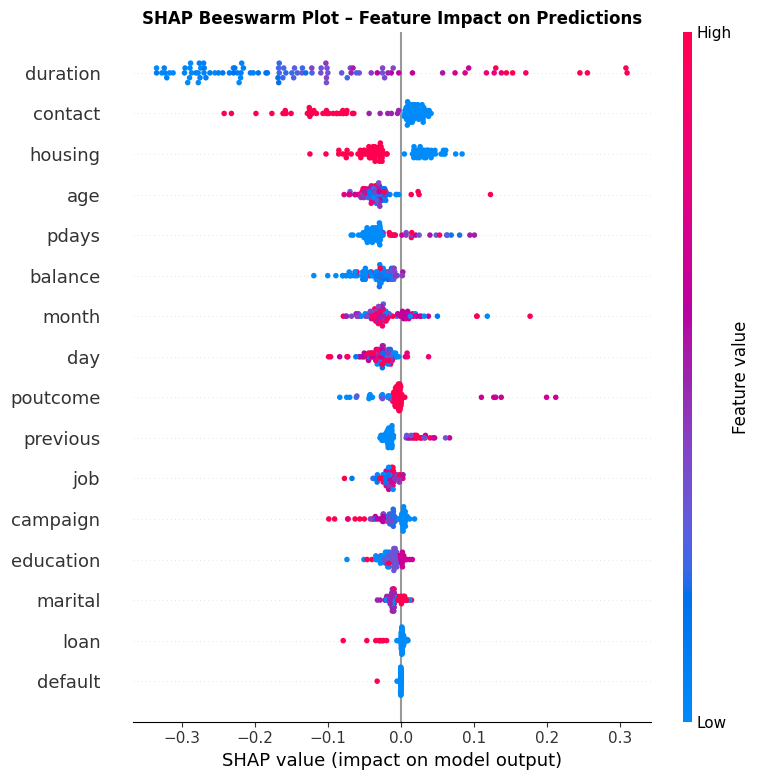

In [16]:
# SHAP Beeswarm (detailed) 
plt.figure()
sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:,:,1]
shap.summary_plot(sv, X_test_sample, show=False)
plt.title('SHAP Beeswarm Plot – Feature Impact on Predictions', fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# 5 Individual SHAP Force Plots (saved as text explanation)
print("SHAP Explanations for 5 Individual Predictions")
print("=" * 60)
shap_df = pd.DataFrame(sv[:5], columns=X_test_sample.columns)

for i in range(5):
    pred_class = rf.predict(X_test_sample.iloc[[i]])[0]
    pred_prob  = rf.predict_proba(X_test_sample.iloc[[i]])[0][1]
    top_feats  = shap_df.iloc[i].abs().sort_values(ascending=False).head(4)
    
    print(f"\nPrediction #{i+1}:")
    print(f"  Predicted: {'Subscribed (Yes)' if pred_class==1 else 'Not Subscribed (No)'}")
    print(f"  Probability of subscription: {pred_prob:.3f}")
    print(f"  Top influential features:")
    for feat, val in top_feats.items():
        direction = '↑ pushes toward Yes' if shap_df.iloc[i][feat] > 0 else '↓ pushes toward No'
        print(f"    • {feat}: SHAP={shap_df.iloc[i][feat]:.4f}  {direction}")

SHAP Explanations for 5 Individual Predictions

Prediction #1:
  Predicted: Not Subscribed (No)
  Probability of subscription: 0.000
  Top influential features:
    • duration: SHAP=-0.1027  ↓ pushes toward No
    • contact: SHAP=-0.1020  ↓ pushes toward No
    • pdays: SHAP=-0.0392  ↓ pushes toward No
    • housing: SHAP=-0.0377  ↓ pushes toward No

Prediction #2:
  Predicted: Not Subscribed (No)
  Probability of subscription: 0.000
  Top influential features:
    • duration: SHAP=-0.1615  ↓ pushes toward No
    • contact: SHAP=-0.1005  ↓ pushes toward No
    • pdays: SHAP=-0.0403  ↓ pushes toward No
    • housing: SHAP=-0.0359  ↓ pushes toward No

Prediction #3:
  Predicted: Not Subscribed (No)
  Probability of subscription: 0.000
  Top influential features:
    • duration: SHAP=-0.1467  ↓ pushes toward No
    • contact: SHAP=-0.1253  ↓ pushes toward No
    • housing: SHAP=-0.0420  ↓ pushes toward No
    • pdays: SHAP=-0.0394  ↓ pushes toward No

Prediction #4:
  Predicted: Not Subsc

## 7. Conclusion & Insights
- **Random Forest outperforms Logistic Regression** on this imbalanced dataset, achieving higher F1 and AUC scores.
- The most important features are `duration` (call duration), `poutcome` (previous campaign outcome), `balance`, and `age`.
- SHAP analysis confirms that a **longer call duration** strongly pushes predictions toward subscription.
- Customers with a **successful previous campaign outcome** are far more likely to subscribe again.
- **Class imbalance** (~88% No, ~12% Yes) is a key challenge; `class_weight='balanced'` was used to mitigate this.
- **Recommendation:** Target customers with previous successful outcomes and longer engagement history for higher conversion rates.